In [1]:
import os
import glob
import numpy as np
import pandas as pd
from tqdm import tqdm
import librosa
import librosa.display
import matplotlib.pyplot as plt
import random
import torch

import warnings
warnings.filterwarnings("ignore")

In [2]:
#----------------------------- DON'T CHANGE THIS --------------------------
DATA_SEED = 67
TRAINING_SEED = 1234
SR = 22050
DURATION = 5.0
N_FFT = 2048
HOP_LENGTH = 512
N_MELS = 128
TOP_DB=20
TARGET_SNR_DB = 10

random.seed(DATA_SEED)
np.random.seed(DATA_SEED)
torch.manual_seed(DATA_SEED)
torch.cuda.manual_seed(DATA_SEED)

In [3]:
# CONFIGURATION
DATA_ROOT = "/kaggle/input/competitions/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"
GENRES = [
    "blues",
    "classical",
    "country",
    "disco",
    "hiphop",
    "jazz",
    "metal",
    "pop",
    "reggae",
    "rock"
]
STEMS = {
    "drums": "drums.wav",
    "vocals": "vocals.wav",
    "bass": "bass.wav",
    "other": "other.wav"
}
STEM_KEYS = ['drums', 'vocals', 'bass', 'other']
GENRE_TO_TEST = 'rock'
SONG_INDEX = 0

# Data Exploration

In [4]:
def build_dataset(root_dir, val_split=0.17, seed=42):

    # Initialize empty dictionaries
    train_dataset = {g: {s.replace('.wav', ''): [] for s in STEMS.values()} for g in GENRES}
    val_dataset   = {g: {s.replace('.wav', ''): [] for s in STEMS.values()} for g in GENRES}

    rng = random.Random(seed)

    for genre in GENRES:
        genre_path = os.path.join(root_dir, genre)

        if not os.path.isdir(genre_path):
            print(f"[WARN] Genre folder missing: {genre}")
            continue

        valid_songs = []

        # ----------------- Scan all song folders -----------------
        for song in sorted(os.listdir(genre_path)):
            song_path = os.path.join(genre_path, song)

            if not os.path.isdir(song_path):
                continue

            # ---- CHECK: completeness of stems only ----
            valid = True
            for stem_file in STEMS.values():
                stem_path = os.path.join(song_path, stem_file)
                if not os.path.exists(stem_path):
                    valid = False
                    break

            if valid:
                valid_songs.append(song_path)

        if len(valid_songs) == 0:
            print(f"[WARN] No valid songs found for genre: {genre}")
            continue

        # ----------------- Stratified Shuffle Split -----------------
        rng.shuffle(valid_songs)
        split_idx = int(len(valid_songs) * (1 - val_split))

        train_songs = valid_songs[:split_idx]
        val_songs   = valid_songs[split_idx:]

        # ----------------- Populate dictionaries -----------------
        def add_to_dict(target_dict, song_list):
            for song_path in song_list:
                for stem_name, stem_file in STEMS.items():
                    target_dict[genre][stem_name].append(
                        os.path.join(song_path, stem_file)
                    )

        add_to_dict(train_dataset, train_songs)
        add_to_dict(val_dataset, val_songs)

    return train_dataset, val_dataset

In [5]:
tr, val = build_dataset(DATA_ROOT)

In [6]:
def find_long_silences(dataset_dict, sr=SR, threshold_sec=DURATION, top_db=30):
    records = []
    total_files = 0

    MIN_GAP_SEC = 0.1  # critical exam constraint

    for genre, stems in dataset_dict.items():
        for stem_name, file_list in stems.items():
            for file_path in file_list:
                total_files += 1
                try:
                    y, sr = librosa.load(file_path, sr=sr)
                    total_duration = len(y) / sr

                    intervals = librosa.effects.split(y, top_db=top_db)

                    silence_segments = []
                    silence_type = set()

                    # FULL SILENCE
                    if len(intervals) == 0:
                        max_silence = total_duration
                        silence_type.add("full")

                    else:
                        # START
                        start_gap = intervals[0][0] / sr
                        if start_gap >= MIN_GAP_SEC:
                            silence_segments.append(start_gap)
                            silence_type.add("start")

                        # MIDDLE
                        for i in range(len(intervals) - 1):
                            gap = (intervals[i+1][0] - intervals[i][1]) / sr
                            if gap >= MIN_GAP_SEC:
                                silence_segments.append(gap)
                                silence_type.add("middle")

                        # END
                        end_gap = (len(y) - intervals[-1][1]) / sr
                        if end_gap >= MIN_GAP_SEC:
                            silence_segments.append(end_gap)
                            silence_type.add("end")

                        max_silence = max(silence_segments) if silence_segments else 0

                    if max_silence >= threshold_sec:
                        records.append({
                            "Genre": genre,
                            "Stem": stem_name,
                            "Duration": round(total_duration, 2),
                            "Max_Silence_Sec": round(max_silence, 2),
                            "Silence_Location": ",".join(sorted(silence_type)),
                            "File_Path": file_path
                        })

                except:
                    continue

    print(f"[INFO] Total files scanned: {total_files}")
    return pd.DataFrame(records)

In [7]:
df_silence = find_long_silences(tr, threshold_sec=DURATION, top_db=TOP_DB)
df_silence.shape

[INFO] Total files scanned: 3320


(680, 6)

In [8]:
df_silence.head()

,Genre,Stem,Duration,Max_Silence_Sec,Silence_Location,File_Path
0,blues,drums,30.01,16.28,"end,middle,start",/kaggle/input/competitions/jan-2026-dl-gen-ai-...
1,blues,drums,30.01,12.35,"middle,start",/kaggle/input/competitions/jan-2026-dl-gen-ai-...
2,blues,drums,30.01,11.26,"end,middle,start",/kaggle/input/competitions/jan-2026-dl-gen-ai-...
3,blues,drums,30.01,9.57,"end,middle",/kaggle/input/competitions/jan-2026-dl-gen-ai-...
4,blues,drums,30.01,10.89,"end,middle,start",/kaggle/input/competitions/jan-2026-dl-gen-ai-...


In [9]:
stems_audio = []
try:
    for key in STEM_KEYS:
        # Get stem list for selected genre
        stem_files = tr[GENRE_TO_TEST][key]

        # Select song by index
        file_path = stem_files[SONG_INDEX]

        # Load audio (Duration 5.0s for speed/consistency)
        y, sr = librosa.load(file_path, sr=SR, duration=5.0)

        stems_audio.append(y)

    print("Audio loaded successfully.")

except NameError:
    print("ERROR: 'tr' dictionary not found. Please run build_dataset() first.")
except IndexError:
    print(f"ERROR: Song index {SONG_INDEX} out of range for genre {GENRE_TO_TEST}.")
except Exception as e:
    print(f"ERROR: {e}")

Audio loaded successfully.


In [10]:
# ------------------- write your code here -------------------------------

# Stack them into a numpy array (Shape: 4 x Samples)
stems_stack = np.stack(stems_audio, axis=0)

# Mix the stems by summing them element-wise
mix_raw = np.sum(stems_stack, axis=0)

# Calculate RMS Amplitude MANUALLY
rms_val = np.sqrt(np.mean(mix_raw ** 2))

# Peak Normalization
max_val = np.max(np.abs(mix_raw))

if max_val > 0:
    mix_norm = mix_raw / max_val
else:
    mix_norm = mix_raw

# VALIDATION
assert np.isclose(np.max(np.abs(mix_norm)), 1.0), "Normalization failed."
#-------------------------------------------------------------------------

# Milestone 2

In [11]:
def load_audio_safe(path, sr=None):
    try:
        if os.path.getsize(path) == 0:
            return None, None
        y, sr = librosa.load(path, sr=sr)
        if len(y) == 0:
            return None, None
        return y, sr
    except:
        return None, None

In [12]:
def extract_features(y, sr, n_mfcc=20):
    features = {}

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    features["mfcc_mean"] = mfcc.mean(axis=1)

    spec_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    features["spec_centroid_mean"] = spec_centroid.mean()

    spec_bw = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    features["spec_bw_mean"] = spec_bw.mean()

    zcr = librosa.feature.zero_crossing_rate(y)
    features["zcr_mean"] = zcr.mean()

    rms = librosa.feature.rms(y=y)
    features["rms_mean"] = rms.mean()

    return features

In [13]:
def build_feature_dataframe(dataset_dict):
    rows = []

    for genre, stems in tqdm(dataset_dict.items()):
        for stem, files in stems.items():
            for path in files:
                y, sr = load_audio_safe(path)
                if y is None:
                    continue

                feats = extract_features(y, sr)
                feats["genre"] = genre
                feats["stem"] = stem
                feats["duration"] = len(y) / sr
                feats["sample_rate"] = sr
                feats["path"] = path

                rows.append(feats)

    return pd.DataFrame(rows)

In [14]:
df_train = build_feature_dataframe(tr)
df_train.head()

100%|██████████| 10/10 [26:44<00:00, 160.41s/it]


,mfcc_mean,spec_centroid_mean,spec_bw_mean,zcr_mean,rms_mean,genre,stem,duration,sample_rate,path
0,"[-397.70853, 29.20259, -54.695656, 87.72036, 5...",4369.060981,2227.866982,0.175308,0.028826,blues,drums,30.013333,44100,/kaggle/input/competitions/jan-2026-dl-gen-ai-...
1,"[-373.92484, 62.689117, -41.215122, 106.50217,...",3462.480061,2500.551531,0.115352,0.039184,blues,drums,30.013333,44100,/kaggle/input/competitions/jan-2026-dl-gen-ai-...
2,"[-463.6414, 84.68878, -11.023653, 13.312096, -...",2608.313073,2471.869264,0.079077,0.014461,blues,drums,30.013333,44100,/kaggle/input/competitions/jan-2026-dl-gen-ai-...
3,"[-593.8848, 91.355736, -70.01895, 38.140163, 3...",3036.436918,2198.084495,0.114204,0.002715,blues,drums,30.013333,44100,/kaggle/input/competitions/jan-2026-dl-gen-ai-...
4,"[-398.79147, 119.01798, -63.325104, 57.15389, ...",2947.334800,1986.896746,0.120679,0.021080,blues,drums,30.013333,44100,/kaggle/input/competitions/jan-2026-dl-gen-ai-...


In [15]:
q1 = df_train[df_train.genre == "jazz"]["duration"].mean()
print("q1 ",q1)


q2 =sorted(df_train["sample_rate"].unique().tolist())
print("q2 ",q2)

corrupted_count = 0
for genre in tr:
    for stem in tr[genre]:
        for path in tr[genre][stem]:
            try:
                if os.path.getsize(path) == 0:
                    corrupted_count += 1
            except:
                corrupted_count += 1
q3=corrupted_count
print("q3 ",q3)


peaks_db = []
for path in df_train[df_train.stem == "vocals"]["path"]:
    y, sr = load_audio_safe(path)
    if y is not None:
        peak = np.max(np.abs(y))
        peak_db = librosa.amplitude_to_db([peak])[0]
        peaks_db.append(peak_db)
q4=np.mean(peaks_db)
print("q4 ",q4)



q5=df_train[df_train.genre == "blues"]["spec_centroid_mean"].mean()
print("q5 ",q5)



q6=df_train.groupby("genre")["spec_centroid_mean"].mean().idxmax()
print("q6 ",q6)




def has_initial_silence(path, silence_sec=0.5, top_db=30):
    y, sr = load_audio_safe(path)
    if y is None:
        return False

    silence_samples = int(silence_sec * sr)
    segment = y[:silence_samples]

    intervals = librosa.effects.split(segment, top_db=top_db)
    return len(intervals) == 0
    
count_initial_silence = sum(
    has_initial_silence(p) for p in df_train["path"]
)
q7=count_initial_silence
print("q7 ",q7)

q1  30.034636505204485
q2  [44100]
q3  0
q4  -12.423471
q5  2324.4457217291647
q6  metal
q7  0


## Milestone 2b

Validation Macro F1 Score: 0.1523

Detailed Classification Report:
              precision    recall  f1-score   support

       blues       0.20      0.10      0.13        10
   classical       0.14      0.10      0.12        10
     country       0.10      0.10      0.10        10
       disco       0.20      0.40      0.27        10
      hiphop       0.25      0.10      0.14        10
        jazz       0.00      0.00      0.00        10
       metal       0.41      0.90      0.56        10
         pop       0.20      0.20      0.20        10
      reggae       0.00      0.00      0.00        10
        rock       0.00      0.00      0.00        10

    accuracy                           0.19       100
   macro avg       0.15      0.19      0.15       100
weighted avg       0.15      0.19      0.15       100



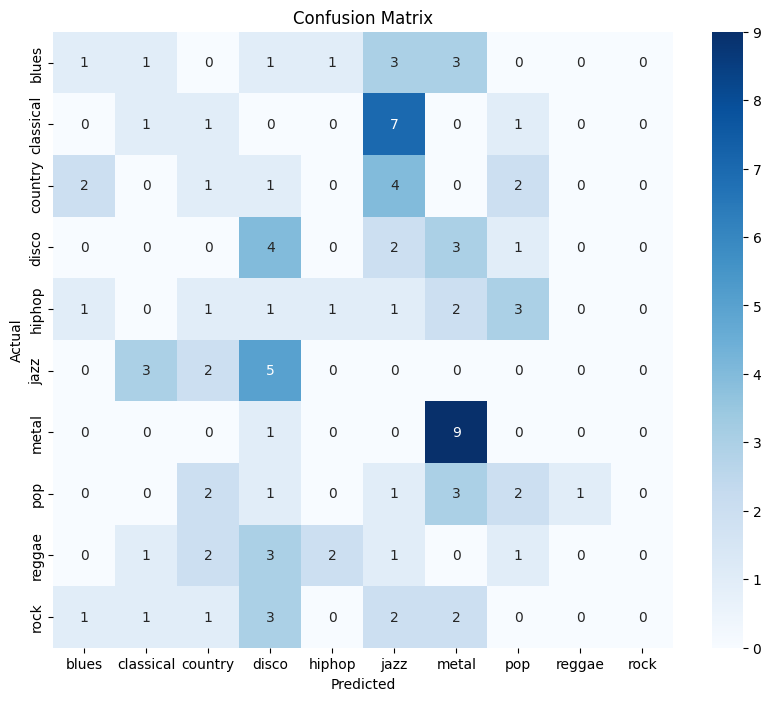

,Genre,TP,FP,FN,TN
0,blues,1,4,9,86
1,classical,1,6,9,84
2,country,1,9,9,81
3,disco,4,16,6,74
4,hiphop,1,3,9,87
5,jazz,0,21,10,69
6,metal,9,13,1,77
7,pop,2,8,8,82
8,reggae,0,1,10,89
9,rock,0,0,10,90


In [16]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# --- 1. Setup and Preprocessing ---
ROOT = '/kaggle/input/competitions/jan-2026-dl-gen-ai-project/messy_mashup'
STEMS_PATH = os.path.join(ROOT, 'genres_stems')
GENRES = ["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"]

def extract_features(song_path):
    # Load 10s at 22050Hz
    y, sr = librosa.load(os.path.join(song_path, 'other.wav'), sr=22050, duration=10)
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    spec_cent = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    return [float(tempo), spec_cent, zcr, rolloff]

# --- 2. Data Preparation & Stratified Split ---
data = []
for g in GENRES:
    gp = os.path.join(STEMS_PATH, g)
    songs = [s for s in os.listdir(gp) if os.path.isdir(os.path.join(gp, s))]
    for s in songs[:50]: # Sampling 50 for speed; use all for final
        data.append({'path': os.path.join(gp, s), 'genre': g})

df = pd.DataFrame(data)
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['genre'], random_state=42)

# --- 3. Model Training (Decision Tree) ---
X_train = np.array([extract_features(p) for p in train_df['path']])
y_train = train_df['genre']
X_val = np.array([extract_features(p) for p in val_df['path']])
y_val = val_df['genre']

clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)
# --- Prediction & Evaluation ---

y_pred = clf.predict(X_val)

macro_f1 = f1_score(y_val, y_pred, average="macro")

cm = confusion_matrix(y_val, y_pred, labels=GENRES)

cr = classification_report(y_val, y_pred)

print(f"Validation Macro F1 Score: {macro_f1:.4f}\n")
print("Detailed Classification Report:")
print(cr)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    xticklabels=GENRES,
    yticklabels=GENRES,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

tp = np.diag(cm)
fp = cm.sum(axis=0) - tp
fn = cm.sum(axis=1) - tp
tn = cm.sum() - (tp + fp + fn)

metrics_df = pd.DataFrame({
    "Genre": GENRES,
    "TP": tp,
    "FP": fp,
    "FN": fn,
    "TN": tn
})

metrics_df

In [17]:
q1 = macro_f1
print(q1)
print(classification_report(y_val, y_pred, output_dict=True)["hiphop"]["precision"])
print(classification_report(y_val, y_pred, output_dict=True)["hiphop"]["precision"])
from sklearn.metrics import accuracy_score
q4=accuracy_score(y_val, y_pred)
q5=metrics_df.loc[metrics_df.TP.idxmax(), "Genre"]
q6=metrics_df.loc[metrics_df.FN.idxmin(), "Genre"]
print(q4)
print(q5)
print(q6)

0.15230042016806722
0.25
0.25
0.19
metal
metal


In [18]:
#----------------------------- DON'T CHANGE THIS --------------------------
DATA_SEED = 67
TRAINING_SEED = 1234
SR = 22050
DURATION = 5.0
N_FFT = 2048
HOP_LENGTH = 512
N_MELS = 128
TOP_DB=20
TARGET_SNR_DB = 10

random.seed(DATA_SEED)
np.random.seed(DATA_SEED)
torch.manual_seed(DATA_SEED)
torch.cuda.manual_seed(DATA_SEED)

In [19]:
# CONFIGURATION
DATA_ROOT = "/kaggle/input/competitions/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"
GENRES = [
    "blues",
    "classical",
    "country",
    "disco",
    "hiphop",
    "jazz",
    "metal",
    "pop",
    "reggae",
    "rock"
]
STEMS = {
    "drums": "drums.wav",
    "vocals": "vocals.wav",
    "bass": "bass.wav",
    "other": "other.wav"
}
STEM_KEYS = ['drums', 'vocals', 'bass', 'other']
GENRE_TO_TEST = 'rock'
SONG_INDEX = 0

In [20]:
q1 = macro_f1
print(q1)
print(classification_report(y_val, y_pred, output_dict=True)["hiphop"]["precision"])
print(classification_report(y_val, y_pred, output_dict=True)["hiphop"]["precision"])
from sklearn.metrics import accuracy_score
q4=accuracy_score(y_val, y_pred)
q5=metrics_df.loc[metrics_df.TP.idxmax(), "Genre"]
q6=metrics_df.loc[metrics_df.FN.idxmin(), "Genre"]
print(q4)
print(q5)
print(q6)

0.15230042016806722
0.25
0.25
0.19
metal
metal
